In [23]:
# General
import numpy as np
import pandas as pd

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model Selection
from sklearn.model_selection import train_test_split

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

# Imbalance Handling
from imblearn.over_sampling import SMOTE

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Loading Dataset
creditcard_dataset = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")

In [25]:
# Standarizing Data
scaler = StandardScaler()
creditcard_dataset["Amount"] = scaler.fit_transform(creditcard_dataset[["Amount"]])

In [26]:
# Standarizing Time
creditcard_dataset["Hour"] = (creditcard_dataset["Time"] // 3600) % 24
creditcard_dataset.drop("Time", axis=1, inplace=True)

In [27]:
# Setting Target Coloumn
X = creditcard_dataset.drop("Class", axis=1)
Y = creditcard_dataset["Class"]

In [28]:
# Train-Text Split
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.2,stratify=Y, random_state=2)

In [29]:
# Calculating Ratio
ratio = len(Y_train[Y_train == 0]) / len(Y_train[Y_train == 1])

In [30]:
# Train XGB
model = XGBClassifier(
    scale_pos_weight=ratio,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='auc'
)

model.fit(X_train, Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

MODEL EVALUATION RESULTS

📊 Classification Report:

              precision    recall  f1-score   support

           0     0.9998    0.9998    0.9998     56864
           1     0.8842    0.8571    0.8705        98

    accuracy                         0.9996     56962
   macro avg     0.9420    0.9285    0.9351     56962
weighted avg     0.9996    0.9996    0.9996     56962

📈 ROC-AUC Score: 0.9899

🧾 Confusion Matrix:
[[56853    11]
 [   14    84]]

🔍 Detailed Breakdown:
True Negatives: 56853
False Positives: 11
False Negatives (missed fraud): 14
True Positives (detected fraud): 84


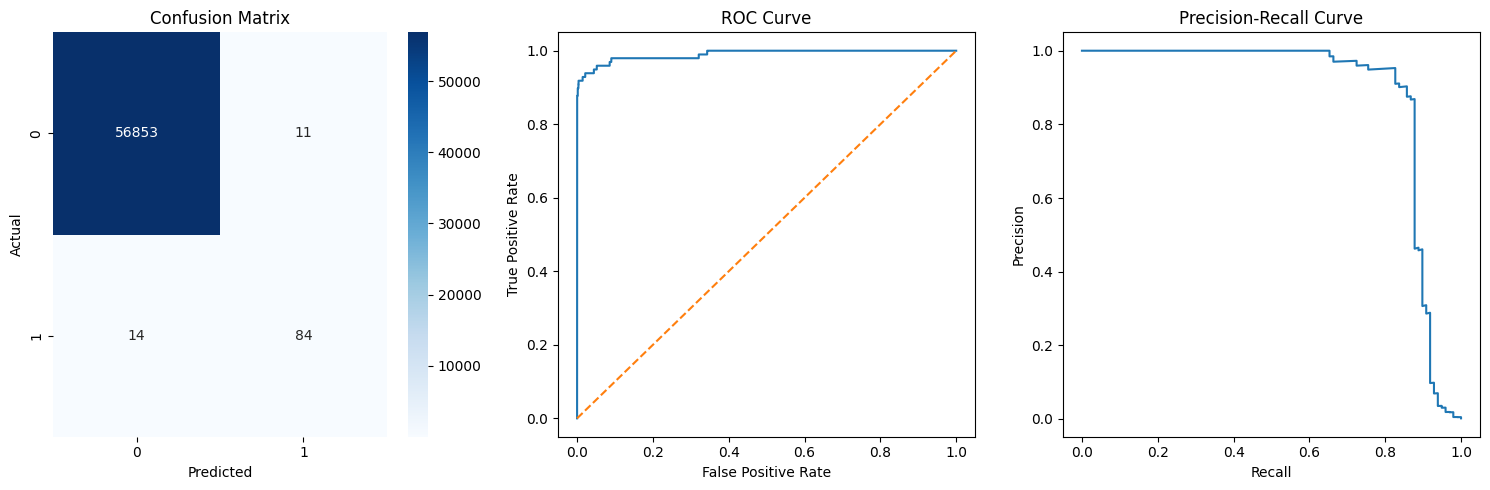

In [31]:
# Predictions
Y_pred = model.predict(X_test)
Y_prob = model.predict_proba(X_test)[:, 1]

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

roc = roc_auc_score(Y_test, Y_prob)
cm = confusion_matrix(Y_test, Y_pred)

# ===== PRINT RESULTS =====
print("="*50)
print("MODEL EVALUATION RESULTS")
print("="*50)

print("\n📊 Classification Report:\n")
print(classification_report(Y_test, Y_pred, digits=4))

print("📈 ROC-AUC Score: {:.4f}".format(roc))

tn, fp, fn, tp = cm.ravel()

print("\n🧾 Confusion Matrix:")
print(cm)

print("\n🔍 Detailed Breakdown:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives (missed fraud): {fn}")
print(f"True Positives (detected fraud): {tp}")

print("="*50)


# ===== VISUALIZATIONS =====

plt.figure(figsize=(15,5))

# 1. Confusion Matrix
plt.subplot(1,3,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(Y_test, Y_prob)

plt.subplot(1,3,2)
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(Y_test, Y_prob)

plt.subplot(1,3,3)
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.tight_layout()
plt.show()